Import Libaries

In [100]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns


Load Data

In [101]:
df = pd.read_csv("../Data/data.csv", encoding='latin-1')

In [102]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Data Understanding

In [103]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [104]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Checking null Values

In [105]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data Preprocessing

In [106]:
df.dropna(inplace=True)

In [107]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [108]:
df.shape and df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [109]:
# Converts date column to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [110]:
# Creates new feature as total money spent per transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

FEATURE ENGINEERING (RFM)

In [111]:
# Gets the latest date in the dataset and adds one day to it
latest_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [112]:
latest_date

Timestamp('2011-12-10 12:50:00')

In [113]:
# Creates RFM features
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})

In [114]:
# Rename columns and resets index
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

In [115]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,182,4310.00
2,12348.0,75,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,310,17,334.40


In [116]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Exploratory Data Analysis (EDA)

In [117]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  str           
 1   StockCode    406829 non-null  str           
 2   Description  406829 non-null  str           
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  str           
 8   TotalAmount  406829 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 51.0 MB


In [118]:
# customers who have cancelled orders (InvoiceNo starts with 'C')
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8905)

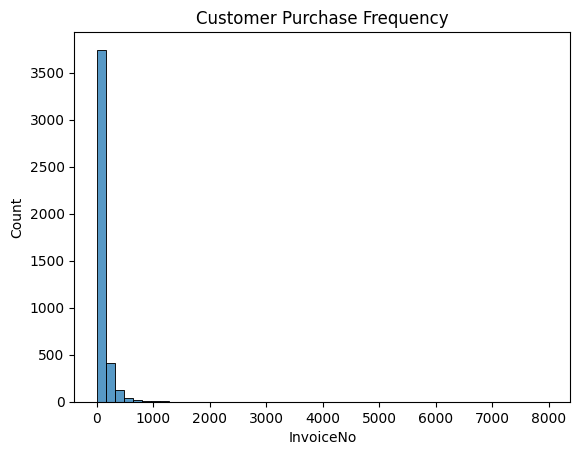

In [119]:
# Customer purchase frequency distribution
purchase_freq = df.groupby('CustomerID')['InvoiceNo'].count()

sns.histplot(purchase_freq, bins=50)
plt.title("Customer Purchase Frequency")
plt.show()

In [120]:
# Top 10 customers by total amount spent
print("Top 10 Customers by Total Amount Spent:")
df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

Top 10 Customers by Total Amount Spent:


CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: TotalAmount, dtype: float64

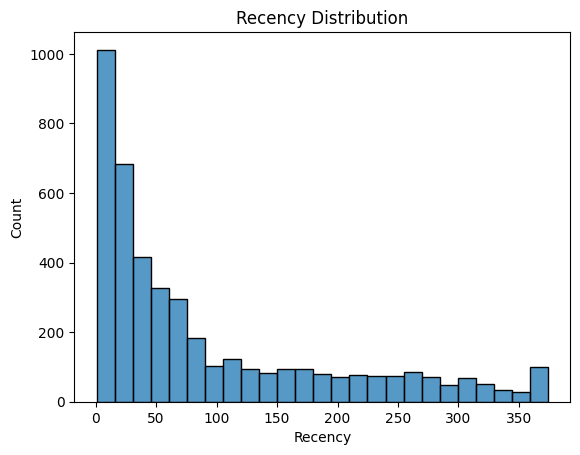

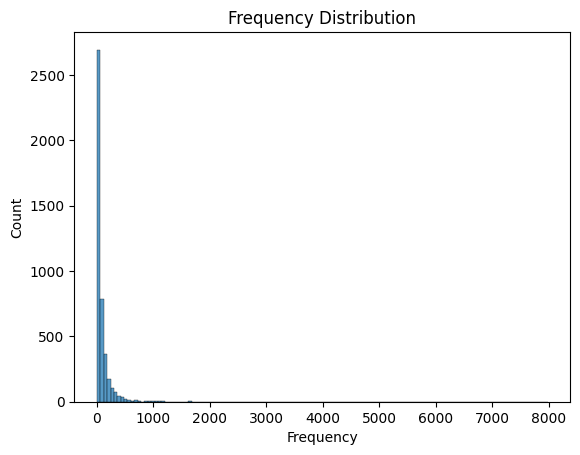

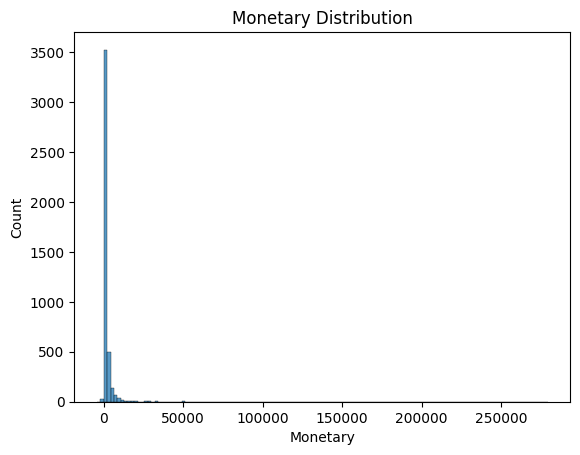

In [121]:
sns.histplot(rfm['Recency'])
plt.title("Recency Distribution")
plt.show()

sns.histplot(rfm['Frequency'])
plt.title("Frequency Distribution")
plt.show()

sns.histplot(rfm['Monetary'])
plt.title("Monetary Distribution")
plt.show()

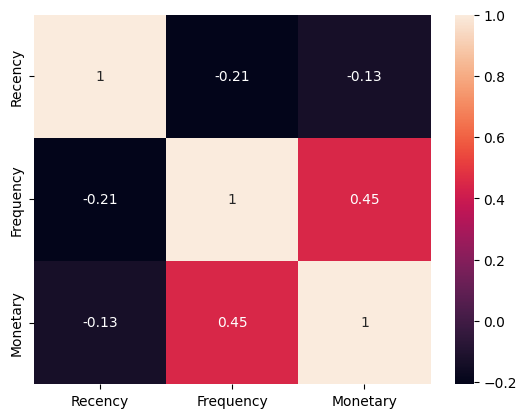

In [122]:
# Correlation heatmap of RFM features
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True)
plt.show()

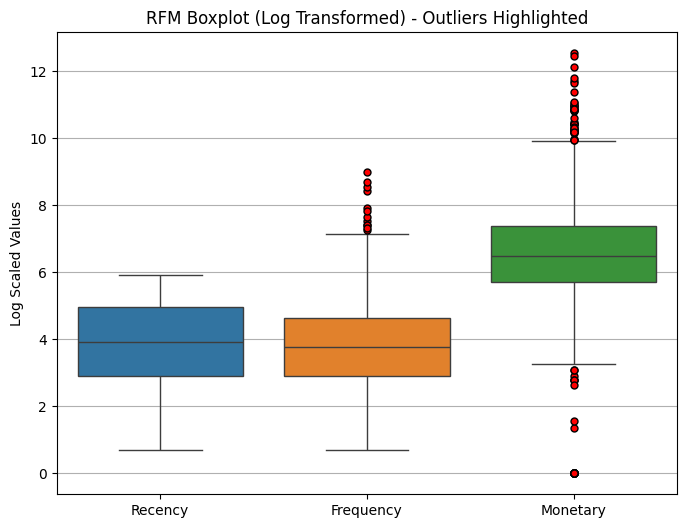

In [123]:
#Log transformation
rfm_log = rfm[['Recency','Frequency','Monetary']].apply(np.log1p)

# Boxplot with clear outliers
plt.figure(figsize=(8,6))

sns.boxplot(
    data=rfm_log,
    showfliers=True,  # ensure outliers are visible
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markersize=5,
        linestyle='none',
        markeredgecolor='black'
    )
)

plt.title("RFM Boxplot (Log Transformed) - Outliers Highlighted")
plt.ylabel("Log Scaled Values")
plt.grid(axis='y')

In [124]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

K-Means Clustering with elbow method

In [125]:
from sklearn.cluster import KMeans
inertia = []

for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

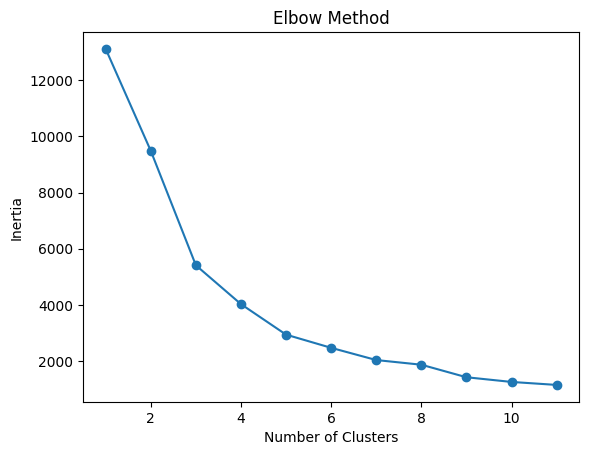

In [126]:
plt.plot(range(1,12), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

K-Means Clustering using Knee Method


In [127]:
!pip install kneed


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [128]:
from kneed import KneeLocator
knee = KneeLocator(range(1,12), inertia, curve='convex', direction='decreasing')
knee.elbow

np.int64(4)

In [129]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [130]:
from sklearn.metrics import silhouette_score
K_means_score = silhouette_score(rfm_scaled, rfm['Cluster'])
K_means_score

0.5997200972195096

HIERARCHICAL CLUSTERING USING DENDROGRAM

In [131]:
from scipy.cluster.hierarchy import dendrogram, linkage

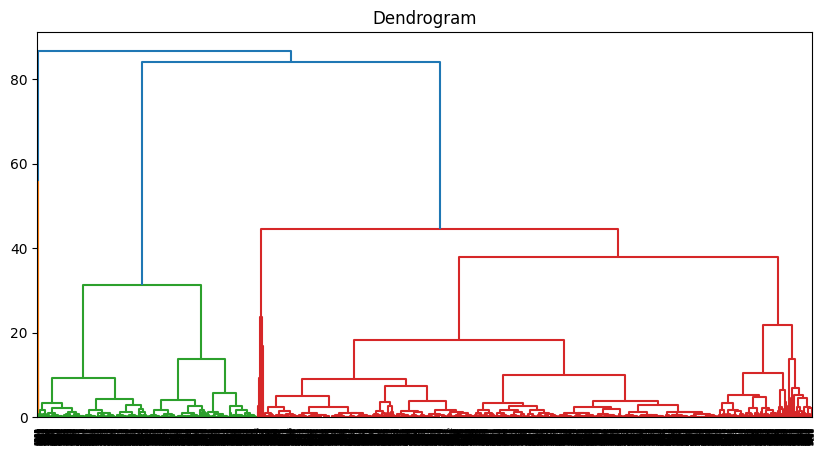

In [132]:
linked = linkage(rfm_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [133]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

# Create cluster labels (same number as KMeans = 4)
hc_labels = fcluster(linked, 4, criterion='maxclust')

# Calculate score
hc_score = silhouette_score(rfm_scaled, hc_labels)

hc_score

0.578351926253426

DBSCAN

In [134]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

In [135]:
labels = rfm['DBSCAN_Cluster']
valid = labels != -1

if len(set(labels[valid])) > 1:
    db_score = silhouette_score(rfm_scaled[valid], labels[valid])
else:
    db_score = -1
print(db_score)

0.672809883016003


In [136]:
# Model Comparison
print("KMeans Clustering:", K_means_score)
print("Hierarchical Clustering:", hc_score) 
print("DBSCAN Clustering:", db_score)

KMeans Clustering: 0.5997200972195096
Hierarchical Clustering: 0.578351926253426
DBSCAN Clustering: 0.672809883016003


DBSCAN Visualizations

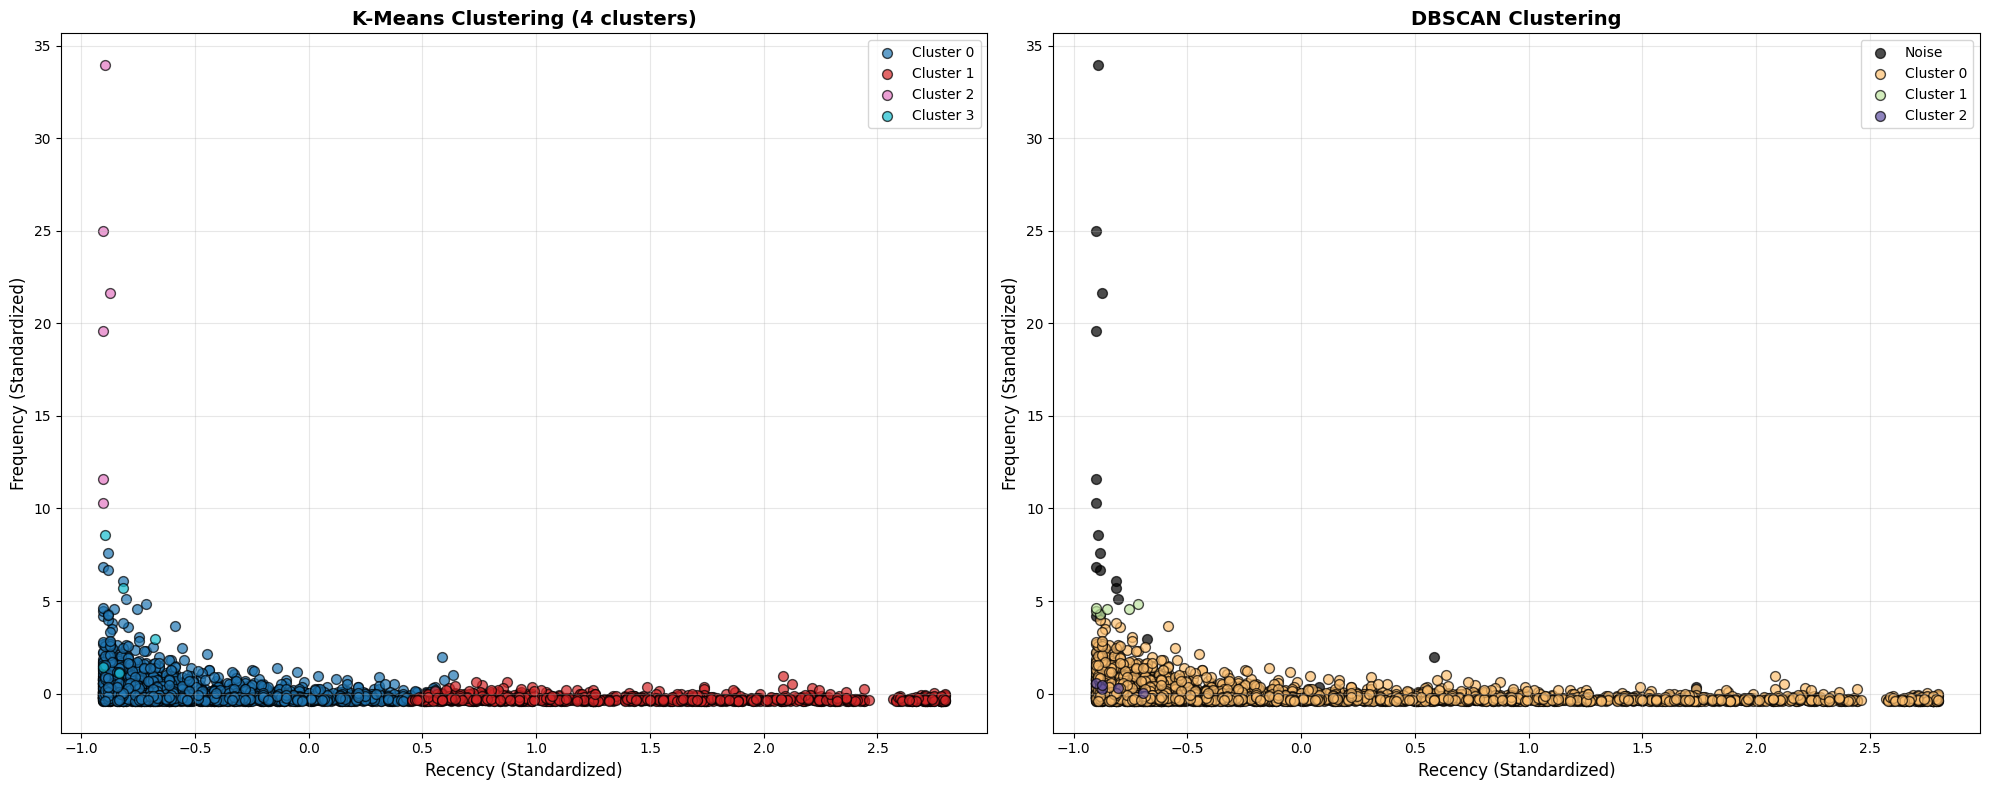

In [ ]:
# Comparison: K-Means vs DBSCAN Clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# K-Means clusters
unique_kmeans = sorted(rfm['Cluster'].unique())
colors_kmeans = plt.cm.tab10(np.linspace(0, 1, len(unique_kmeans)))

for k, col in zip(unique_kmeans, colors_kmeans):
    class_member_mask = (rfm['Cluster'] == k)
    xy = rfm_scaled[class_member_mask]
    ax1.scatter(xy[:, 0], xy[:, 1], c=[col], edgecolor='k', s=50, alpha=0.7,
                label=f'Cluster {k}')

ax1.set_xlabel('Recency (Standardized)', fontsize=12)
ax1.set_ylabel('Frequency (Standardized)', fontsize=12)
ax1.set_title('K-Means Clustering (4 clusters)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# DBSCAN clusters
unique_dbscan = sorted(set(rfm['DBSCAN_Cluster']))
colors_dbscan = plt.cm.Spectral(np.linspace(0, 1, len(unique_dbscan)))

for k, col in zip(unique_dbscan, colors_dbscan):
    if k == -1:
        col = 'black'
    class_member_mask = (rfm['DBSCAN_Cluster'] == k)
    xy = rfm_scaled[class_member_mask]
    ax2.scatter(xy[:, 0], xy[:, 1], c=[col], edgecolor='k', s=50, alpha=0.7,
                label=f'Cluster {k}' if k != -1 else 'Noise')

ax2.set_xlabel('Recency (Standardized)', fontsize=12)
ax2.set_ylabel('Frequency (Standardized)', fontsize=12)
ax2.set_title('DBSCAN Clustering', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Segment labelling

In [144]:
def segment(row):
    if row['Monetary'] > rfm['Monetary'].quantile(0.75):
        return "High Value"
    elif row['Frequency'] > rfm['Frequency'].quantile(0.75):
        return "Loyal"
    elif row['Recency'] > rfm['Recency'].quantile(0.75):
        return "At Risk"
    else:
        return "Low Value"

rfm['Segment'] = rfm.apply(segment, axis=1)

In [145]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,DBSCAN_Cluster,Segment
0,12346.0,326,2,0.00,1,0,At Risk
1,12347.0,2,182,4310.00,0,0,High Value
2,12348.0,75,31,1797.24,0,0,High Value
3,12349.0,19,73,1757.55,0,0,High Value
4,12350.0,310,17,334.40,1,0,At Risk


Predictive Model

In [146]:
rfm['Target'] = (rfm['Monetary'] > rfm['Monetary'].median()).astype(int)

In [147]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,DBSCAN_Cluster,Segment,Target
0,12346.0,326,2,0.00,1,0,At Risk,0
1,12347.0,2,182,4310.00,0,0,High Value,1
2,12348.0,75,31,1797.24,0,0,High Value,1
3,12349.0,19,73,1757.55,0,0,High Value,1
4,12350.0,310,17,334.40,1,0,At Risk,0


In [148]:
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Target']

In [149]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [150]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluation metrics

In [151]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

Save models

In [152]:
import joblib
joblib.dump(model, "../Models/classifier.pkl")
joblib.dump(kmeans, "../Models/kmeans.pkl")
joblib.dump(scaler, "../Models/scaler.pkl")

['../Models/scaler.pkl']

In [153]:
cluster_names = {
    0: "🟢 Regular Customers",
    1: "🔴 At Risk Customers",
    2: "💰 High Value Customers",
    3: "👑 Premium Customers"
}

In [154]:
rfm.to_csv(r"..\Data\rfm_final.csv", index=False)